In [3]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from typing import Optional
import numpy as np
import gymnasium as gym
from collections import Counter

class RL_Bandit_Agent:
    def __init__(self):
        self.alpha = 0.2
        self.B = 2.0
        # self.Q_sa = np.zeros((2, 2))
        self.probs_a = 1
        self.probs_b = 0
        self.action_a = 1
        self.action_b = 0
        self.running_accuracy = None
        self.Q_sa = np.zeros((8, 8,4))
        self.accurate_count_list = []
        self.action = random.choice([0,1,2, 3])
        self.action_0 = 0
        self.action_1 = 1
        self.action_2 = 2
        self.action_3 = 3
        #self.reward = 0

    def softmax(self, Q_sa):
        Q_sa = Q_sa - np.max(Q_sa)
        exp_vals = np.exp(self.B * Q_sa)
        return exp_vals / np.sum(exp_vals)

    def take_action(self, x, y):
        #self.reward = reward
        probs = self.softmax(self.Q_sa[x, y])
        self.action = np.random.choice(len(probs), p=probs)

        #reward = 1 if action == outcome else 0
        #self.Q_sa[self.action] = self.Q_sa[self.action] + self.alpha * (reward - self.Q_sa[self.action])

        # self.accurate_count_list.append(reward)

        # self.running_accuracy = np.cumsum(self.accurate_count_list) / np.arange(
        #     1, len(self.accurate_count_list) + 1
        # )

        return self.action
    
    def update_Q(self, reward, x, y):
        self.Q_sa[x, y, self.action] = self.Q_sa[x, y, self.action] + self.alpha * (reward - self.Q_sa[x, y, self.action])
        #return self.Q_sa

class GridWorldEnv(gym.Env):
    def __init__(self, size: int = 8):
        # The size of the square grid (5x5 by default)
        self.size = size
        self.action = 0

        # Initialize positions - will be set randomly in reset()
        # Using -1,-1 as "uninitialized" state
        self._agent_location = np.array([-1, -1], dtype=np.int32)
        self._target_location = np.array([-1, -1], dtype=np.int32)
        self.dist = None
        self.prev_dist = None
        self.prev_location = None

        # Define what the agent can observe
        # Dict space gives us structured, human-readable observations
        self.observation_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(0, size - 1, shape=(2,), dtype=int),   # [x, y] coordinates
                "target": gym.spaces.Box(0, size - 1, shape=(2,), dtype=int),  # [x, y] coordinates
            }
        )

        # Define what actions are available (4 directions)
        self.action_space = gym.spaces.Discrete(4)

        # Map action numbers to actual movements on the grid
        # This makes the code more readable than using raw numbers
        self._action_to_direction = {
            0: np.array([0, 1]),   # Move right (column + 1)
            1: np.array([-1, 0]),  # Move up (row - 1)
            2: np.array([0, -1]),  # Move left (column - 1)
            3: np.array([1, 0]),   # Move down (row + 1)
        }

        self.hole_coords = {(1, 1), (3, 1), (3, 2)}

    def _get_obs(self):
        """Convert internal state to observation format.

        Returns:
            dict: Observation with agent and target positions
        """
        return {"agent": self._agent_location, "target": self._target_location}
    

    def _get_info(self):
        """Compute auxiliary information for debugging.

        Returns:
            dict: Info with distance between agent and target
        """
        return {
            "distance": np.linalg.norm(
                self._agent_location - self._target_location, ord=1
            )
        }
    

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        """Start a new episode.

        Args:
            seed: Random seed for reproducible episodes
            options: Additional configuration (unused in this example)

        Returns:
            tuple: (observation, info) for the initial state
        """
        # IMPORTANT: Must call this first to seed the random number generator
        super().reset(seed=seed)

        # Randomly place the agent anywhere on the grid
        self._agent_location = np.array([0, 0], dtype=np.int32)

        # Randomly place target, ensuring it's different from agent position
        self._target_location = np.array([3, 3], dtype=np.int32)
        # while np.array_equal(self._target_location, self._agent_location):
        #     self._target_location = self.np_random.integers(
        #         0, self.size, size=2, dtype=int
        #     )

        observation = self._get_obs()
        info = self._get_info()
        self.prev_location = self._agent_location
        self.prev_dist = np.abs(self._agent_location[0] - self._target_location[0] 
                                   +
                                   self._agent_location[1] - self._target_location[1])

        return observation, info
    
    
    def step(self, action):
        """Execute one timestep within the environment.

        Args:
            action: The action to take (0-3 for directions)

        Returns:
            tuple: (observation, reward, terminated, truncated, info)
        """
        # Map the discrete action (0-3) to a movement direction
        direction = self._action_to_direction[action]

        # Update agent position, ensuring it stays within grid bounds
        # np.clip prevents the agent from walking off the edge
        self.prev_location = self._agent_location.copy()

        self._agent_location = np.clip(
            self._agent_location + direction, 0, self.size - 1
        )

        self.dist = (np.abs(self._agent_location[0] - self._target_location[0]) +
                                   np.abs(self._agent_location[1] - self._target_location[1]))

        # Check if agent reached the target
        terminated = np.array_equal(self._agent_location, self._target_location)

        # We don't use truncation in this simple environment
        # (could add a step limit here if desired)
        truncated = False

        # Simple reward structure: +1 for reaching target, 0 otherwise
        # Alternative: could give small negative rewards for each step to encourage efficiency
        observation = self._get_obs()
        info = self._get_info()

        location_as_tuple = tuple(self._agent_location)
        if location_as_tuple in self.hole_coords:
            reward = -5
        elif self.dist < self.prev_dist:
            reward = 1
        elif self.dist == self.prev_dist:
            reward = 0
        else:
            reward = -1
        #reward = 1 if self.dist < self.prev_dist else 0
        #reward = 1 if self._agent_location == self._target_location else 0

        self.prev_dist = self.dist

        return observation, reward, terminated, truncated, info


env = GridWorldEnv()
agent = RL_Bandit_Agent()
env.reset()
terminated = False
path = []
for step in range(0, 500):
    if terminated == False:
        action = agent.take_action(env._agent_location[0], env._agent_location[1])
        observation, reward, terminated, truncated, info = env.step(action)
        agent.update_Q(reward, env.prev_location[0], env.prev_location[1])
        print(env.prev_location[0], env.prev_location[1])
        path.append(tuple(env._agent_location))


path = np.array(path)

plt.scatter(path[:,1], path[:,0])
plt.gca().invert_yaxis()
plt.title("Agent trajectory")
plt.show()

NameError: name 'random' is not defined

[[[ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]]

 [[ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     ]
  [ 0.       0.       0.       0.     

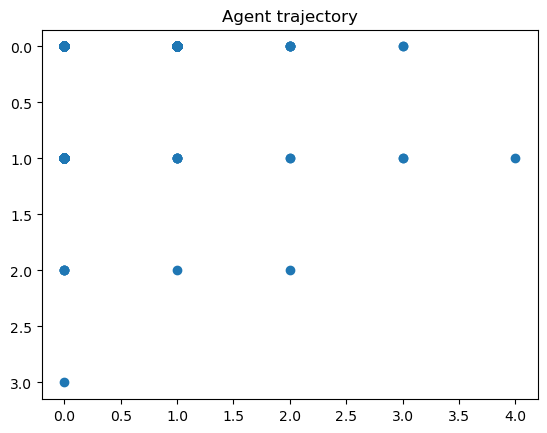

,dx,dy,Right,Up,Left,Down,Best
0,-7,-7,0.00,0.00,0.00,0.00,Right
1,-7,-6,0.00,0.00,0.00,0.00,Right
2,-7,-5,0.00,0.00,0.00,0.00,Right
3,-7,-4,0.00,0.00,0.00,0.00,Right
4,-7,-3,0.00,0.00,0.00,0.00,Right
5,-7,-2,0.00,0.00,0.00,0.00,Right
6,-7,-1,0.00,0.00,0.00,0.00,Right
7,-7,0,0.00,0.00,0.00,0.00,Right
8,-7,1,0.00,0.00,0.00,0.00,Right
9,-7,2,0.00,0.00,0.00,0.00,Right


In [14]:
from typing import Optional
import numpy as np
import gymnasium as gym
from collections import Counter

class RL_Bandit_Agent:
    def __init__(self):
        self.alpha = 0.2
        self.B = 5.0
        # self.Q_sa = np.zeros((2, 2))
        self.probs_a = 1
        self.probs_b = 0
        self.action_a = 1
        self.action_b = 0
        self.running_accuracy = None
        self.Q_sa = np.zeros((15,15,4))
        self.accurate_count_list = []
        self.action = random.choice([0,1,2,3])
        self.action_0 = 0
        self.action_1 = 1
        self.action_2 = 2
        self.action_3 = 3
        #self.reward = 0

    def softmax(self, Q_sa):
        #Q_sa = Q_sa[dist_to_tgt, x, y]
        Q_sa = Q_sa - np.max(Q_sa)
        exp_vals = np.exp(self.B * Q_sa)
        return (exp_vals / np.sum(exp_vals))

    def take_action(self, x, y, det: bool):
        #self.reward = reward
        probs = self.softmax(self.Q_sa[x, y])
        #print(probs.shape)
        if det:
            self.action = np.argmax(probs)
        else:
            self.action = np.random.choice(len(probs), p=probs)

        #reward = 1 if action == outcome else 0
        #self.Q_sa[self.action] = self.Q_sa[self.action] + self.alpha * (reward - self.Q_sa[self.action])

        # self.accurate_count_list.append(reward)

        # self.running_accuracy = np.cumsum(self.accurate_count_list) / np.arange(
        #     1, len(self.accurate_count_list) + 1
        # )

        return self.action
    
    def update_Q(self,reward, dx, dy):
        self.Q_sa[dx,dy,self.action] = self.Q_sa[ dx, dy, self.action] + self.alpha * (reward - self.Q_sa[dx, dy, self.action])
        #return self.Q_sa

class GridWorldEnv(gym.Env):
    def __init__(self, size: int = 8):
        # The size of the square grid (8x8)
        self.size = size
        self.action = 0

        # Initialize positions - will be set randomly in reset()
        # Using -1,-1 as "uninitialized" state
        self._agent_location = np.array([0, 0], dtype=np.int32)
        self._target_location = np.array([0, 0], dtype=np.int32)
        self.dist = None
        self.prev_dist = None
        self.prev_location = None
        self.dx = None
        self.dy = None
        self.prev_dx = None
        self.prev_dy = None

        # Define what the agent can observe
        # Dict space gives us structured, human-readable observations
        self.observation_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(0, size - 1, shape=(2,), dtype=int),   # [x, y] coordinates
                "target": gym.spaces.Box(0, size - 1, shape=(2,), dtype=int),  # [x, y] coordinates
            }
        )

        # Define what actions are available (4 directions)
        self.action_space = gym.spaces.Discrete(4)

        # Map action numbers to actual movements on the grid
        # This makes the code more readable than using raw numbers
        self._action_to_direction = {
            0: np.array([0, 1]),   # Move right (column + 1)
            1: np.array([-1, 0]),  # Move up (row - 1)
            2: np.array([0, -1]),  # Move left (column - 1)
            3: np.array([1, 0]),   # Move down (row + 1)
        }

        #self.hole_coords = {(1, 1), (3, 1), (3, 2), (5, 3), (2, 7)}

    def _get_obs(self):
        """Convert internal state to observation format.

        Returns:
            dict: Observation with agent and target positions
        """
        return {"agent": self._agent_location, "target": self._target_location}
    

    def _get_info(self):
        """Compute auxiliary information for debugging.

        Returns:
            dict: Info with distance between agent and target
        """
        return {
            "distance": np.linalg.norm(
                self._agent_location - self._target_location, ord=1
            )
        }
    

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        """Start a new episode.

        Args:
            seed: Random seed for reproducible episodes
            options: Additional configuration (unused in this example)

        Returns:
            tuple: (observation, info) for the initial state
        """
        # IMPORTANT: Must call this first to seed the random number generator
        super().reset(seed=seed)

        # Randomly place the agent anywhere on the grid
        self._agent_location = np.array([0, 0], dtype=np.int32)

        # Randomly place target in the bottom right corner
        self._target_location = np.array([7, 7], dtype=np.int32)

        # In reset():
        self._agent_location = np.array([
            np.random.randint(0, 8),
            np.random.randint(0, 8)
        ], dtype=np.int32)

        self._target_location = np.array([
            np.random.randint(0, 8),
            np.random.randint(0, 8)
        ], dtype=np.int32)

        # Make sure they're not the same
        while np.array_equal(self._agent_location, self._target_location):
            self._target_location = np.array([
            np.random.randint(0, 8),
            np.random.randint(0, 8)
            ], dtype=np.int32)

        self.dx = int(self._agent_location[0] - self._target_location[0] + 7)
        self.dy = int(self._agent_location[1] - self._target_location[1] + 7)
        # while np.array_equal(self._target_location, self._agent_location):
        #     self._target_location = self.np_random.integers(
        #         0, self.size, size=2, dtype=int
        #     )

        observation = self._get_obs()
        info = self._get_info()
        self.prev_location = self._agent_location.copy()
        self.prev_dist = np.abs(self._agent_location[0] - self._target_location[0] 
                                +
                                self._agent_location[1] - self._target_location[1])

        self.prev_dx = self.dx
        self.prev_dy = self.dy
        return observation, info
        
    
    def step(self, action):
        """Execute one timestep within the environment.

        Args:
            action: The action to take (0-3 for directions)

        Returns:
            tuple: (observation, reward, terminated, truncated, info)
        """
        # Map the discrete action (0-3) to a movement direction
        direction = self._action_to_direction[action]

        # Update agent position, ensuring it stays within grid bounds
        # np.clip prevents the agent from walking off the edge
        self.prev_location = self._agent_location.copy()

        self._agent_location = np.clip(
            self._agent_location + direction, 0, self.size - 1
        )

        self.dist = (np.abs(self._agent_location[0] - self._target_location[0]) +
                                   np.abs(self._agent_location[1] - self._target_location[1]))
        

        self.dx = int(self._agent_location[0] - self._target_location[0] + 7)
        
        self.dy = int(self._agent_location[1] - self._target_location[1] + 7)


        # Check if agent reached the target
        terminated = np.array_equal(self._agent_location, self._target_location)

        # We don't use truncation in this simple environment
        # (could add a step limit here if desired)
        truncated = False

        # Simple reward structure: +1 for reaching target, 0 otherwise
        # Alternative: could give small negative rewards for each step to encourage efficiency
        observation = self._get_obs()
        info = self._get_info()

        #location_as_tuple = tuple(self._agent_location)
        # if location_as_tuple in self.hole_coords:
        #     reward = -5

        if self.dx < self.prev_dx or self.dy < self.prev_dy :
            reward = 2

        elif self.dx == self.prev_dx or self.dy == self.prev_dy:
            reward = -1

        else: 
            reward = -3


        # if self.dist < self.prev_dist:
        #     reward = 2
        # elif self.dist == self.prev_dist:
        #     reward = -1
        # else:
        #     reward = -3

        reward = reward - 0.5
        #reward = 1 if self.dist < self.prev_dist else 0
        #reward = 1 if self._agent_location == self._target_location else 0

        self.prev_dx = self.dx
        self.prev_dy = self.dy
        #self.prev_dist = self.dist

        return observation, reward, terminated, truncated, info


env = GridWorldEnv()
agent = RL_Bandit_Agent()
env.reset()
terminated = False
path = []
for step in range(0, 100000):
    dx, dy = env.dx, env.dy
    action = agent.take_action(dx, dy, det=0)
    observation, reward, terminated, truncated, info = env.step(action)
    #print(env._agent_location[0], env._agent_location[1], "Rew: ", reward)

    agent.update_Q(reward, dx, dy)
    path.append(tuple(env._agent_location))
    if terminated: 
        env.reset()
        terminated = False
        print(f"Reached target at {env._target_location[0], env._target_location[1]} in {step} steps.")

print(agent.Q_sa)
path = np.array(path)

plt.scatter(path[:,1], path[:,0])
plt.gca().invert_yaxis()
plt.title("Agent trajectory")
plt.show()

import pandas as pd

# Show Q-values for all positions in a readable table
rows = []
actions = ['Right', 'Up', 'Left', 'Down']
for dx in range(-7, 8, 1):
    for dy in range(-7, 8, 1):
        row = {'dx': dx, 'dy': dy}
        for i, a in enumerate(actions):
            row[a] = round(agent.Q_sa[dx, dy, i], 2)
        row['Best'] = actions[np.argmax(agent.Q_sa[dx, dy])]
        rows.append(row)

df = pd.DataFrame(rows)
pd.set_option('display.max_rows', None)
df

In [8]:
env.reset()
env._target_location = np.array([7, 7], dtype=np.int32)
env._agent_location = np.array([0, 0], dtype=np.int32)
start_location = env._agent_location
terminated = False
path = []
step = 0
path.append(tuple(env._agent_location))
while not terminated:
    dx, dy = env.dx, env.dy
    action = agent.take_action(dx, dy, det=1)
    observation, reward, terminated, truncated, info = env.step(action)
    #agent.update_Q(reward, env.prev_location[0], env.prev_location[1])
    print(env.prev_location[0], env.prev_location[1])
    path.append(tuple(env._agent_location))
    step += 1

print("Reached in ", step, " steps.")


path = np.array(path)

fig, ax = plt.subplots(figsize=(6, 6))

# Grid setup 0-7
ax.set_xlim(-0.5, 7.5)
ax.set_ylim(-0.5, 7.5)
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.grid(True)
ax.set_aspect('equal')
ax.invert_yaxis()

# Plot path as connected line
ax.plot(path[:, 1], path[:, 0], '-o', color='blue', markersize=4, linewidth=1, label='Path')

# Start point
#ax.plot(start_location, 's', color='blue', markersize=12, label='Start')

# Target (green)
ax.plot(env._target_location[1], env._target_location[0], '*', color='green', markersize=20, label='Target')

ax.set_title("Agent trajectory")
ax.legend()
plt.show()

(4,)
0 0
(4,)
0 1
(4,)
0 2
(4,)
0 3
(4,)
0 4
(4,)
0 5
(4,)
0 6
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(4,)
0 7
(

KeyboardInterrupt: 